In [ ]:
import os
from sklearn.model_selection import train_test_split
import shutil
import random
import time
import copy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torchvision
from torchvision import datasets , models , transforms
from torch.utils.data import DataLoader

from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

from torch import optim
import torch.nn.functional as F

import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
base_folder = r'/content/drive/My Drive/Dataset'  # in New Folder create Dataset as subfolder and that subfolder contains different classes i.e., Flowering, Growing, Mature, Seeding and Wilting
dataset_folder = os.path.join(base_folder, 'Dataset')
new_folder = os.path.join(base_folder, 'data')


In [ ]:
class_folders = [f for f in os.listdir(dataset_folder) if os.path.isdir(os.path.join(dataset_folder, f))]
class_folders

['Nutrition Deficiency',
 'Curl Virus',
 'White spot',
 'Cercospora Leaf Spot',
 'Bacterial Spot',
 'Healthy Leaf']

In [ ]:
os.makedirs(new_folder, exist_ok=True)

In [ ]:
for class_folder in class_folders:
    class_path = os.path.join(dataset_folder, class_folder)
    images = os.listdir(class_path)

    # Shuffle the images randomly
    random.shuffle(images)

    # Split the images into train, test, and validation sets
    train_images, temp_images = train_test_split(images, train_size=0.8, random_state=42)
    test_images, val_images = train_test_split(temp_images, train_size=0.5, random_state=42)

    # Create folders for train, test, and validation sets within the 'data' folder
    train_folder = os.path.join(new_folder, 'train', class_folder)
    test_folder = os.path.join(new_folder, 'test', class_folder)
    val_folder = os.path.join(new_folder, 'val', class_folder)

    os.makedirs(train_folder, exist_ok=True)
    os.makedirs(test_folder, exist_ok=True)
    os.makedirs(val_folder, exist_ok=True)

    # Move images to the respective folders
    for image in train_images:
        shutil.move(os.path.join(class_path, image), os.path.join(train_folder, image))

    for image in test_images:
        shutil.move(os.path.join(class_path, image), os.path.join(test_folder, image))

    for image in val_images:
        shutil.move(os.path.join(class_path, image), os.path.join(val_folder, image))


In [ ]:
train_folder = os.path.join(new_folder, 'train')
num_total_train_images = sum(len(files) for _, _, files in os.walk(train_folder))

test_folder = os.path.join(new_folder, 'test')
num_total_test_images = sum(len(files) for _, _, files in os.walk(test_folder))

val_folder = os.path.join(new_folder, 'val')
num_total_val_images = sum(len(files) for _, _, files in os.walk(val_folder))

print(f"Total Train Images: {num_total_train_images}")
print(f"Total Test Images: {num_total_test_images}")
print(f"Total Validation Images: {num_total_val_images}")


Total Train Images: 1483
Total Test Images: 185
Total Validation Images: 188


In [ ]:
mean_values = [0.485, 0.456, 0.406]
std_values = [0.229, 0.224, 0.225]

In [ ]:
normalize = transforms.Normalize(mean=mean_values, std=std_values)

In [ ]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=256, scale=(0.8, 1.0)),
    transforms.RandomRotation(30),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    normalize,
])

val_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=256, scale=(0.8, 1.0)),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    normalize,
])

test_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=256, scale=(0.8, 1.0)),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    normalize,
])

In [ ]:
# Create custom dataset
train_dataset = datasets.ImageFolder(os.path.join(new_folder, 'train'), transform=train_transforms)
val_dataset = datasets.ImageFolder(os.path.join(new_folder, 'val'), transform=val_transforms)
test_dataset = datasets.ImageFolder(os.path.join(new_folder, 'test'), transform=test_transforms)

In [ ]:
data_loaders = {x: DataLoader(
                    datasets.ImageFolder(os.path.join(new_folder, x),
                                         transform=train_transforms if x == 'train' else
                                                   val_transforms if x == 'val' else test_transforms),
                    batch_size=32,
                    shuffle=True if x == 'train' else False)
                for x in ['train', 'val', 'test']}

In [ ]:
dataset_sizes = {x: len(datasets.ImageFolder(os.path.join(new_folder, x),
                 transform=train_transforms if x == 'train' else val_transforms if x == 'val' else test_transforms))
                 for x in ['train', 'val', 'test']}

class_names = datasets.ImageFolder(os.path.join(new_folder, 'train'), transform=train_transforms).classes

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [ ]:
class_names, device , dataset_sizes

(['Bacterial Spot',
  'Cercospora Leaf Spot',
  'Curl Virus',
  'Healthy Leaf',
  'Nutrition Deficiency',
  'White spot'],
 device(type='cuda', index=0),
 {'train': 1483, 'val': 188, 'test': 185})

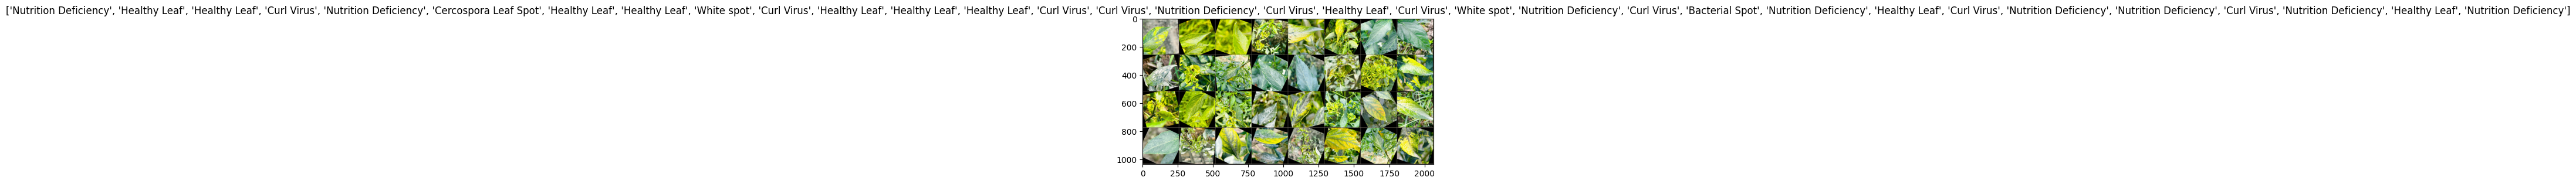

In [ ]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Get a batch of training data from your data loader
inputs, classes = next(iter(data_loaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

# Display the grid using the modified imshow function
imshow(out, title=[class_names[x] for x in classes])

# Show the plot
plt.show()


In [ ]:
help(models)

Help on package torchvision.models in torchvision:

NAME
    torchvision.models

PACKAGE CONTENTS
    _api
    _meta
    _utils
    alexnet
    convnext
    densenet
    detection (package)
    efficientnet
    feature_extraction
    googlenet
    inception
    maxvit
    mnasnet
    mobilenet
    mobilenetv2
    mobilenetv3
    optical_flow (package)
    quantization (package)
    regnet
    resnet
    segmentation (package)
    shufflenetv2
    squeezenet
    swin_transformer
    vgg
    video (package)
    vision_transformer

FILE
    /usr/local/lib/python3.12/dist-packages/torchvision/models/__init__.py




ShuffleNet

In [ ]:
model_ft = models.shufflenet_v2_x1_0(pretrained=True)
print(model_ft)

In [ ]:
for param in model_ft.parameters():
    param.requires_grad = False

In [ ]:
num_classes = 6

model_ft.fc = nn.Sequential(
    nn.Linear(in_features=1024, out_features=256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_classes)
)

print(model_ft)

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_ft.parameters()),
    lr=1e-4
)

In [ ]:
import time
from tqdm import tqdm

def train_and_validate(model, loss_criterion, optimizer, train_data_loader, valid_data_loader, epochs=25, patience=10):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    history = []
    best_acc = 0.0
    best_model_wts = model.state_dict()
    no_improvement = 0

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        # -------- TRAIN --------
        model.train()
        train_loss, train_correct = 0.0, 0

        for inputs, labels in tqdm(train_data_loader, desc="Training"):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            loss = loss_criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()

        # -------- VALIDATION --------
        model.eval()
        valid_loss, valid_correct = 0.0, 0

        with torch.no_grad():
            for inputs, labels in tqdm(valid_data_loader, desc="Validation"):
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = loss_criterion(outputs, labels)

                valid_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                valid_correct += (preds == labels).sum().item()

        # -------- METRICS --------
        avg_train_loss = train_loss / len(train_data_loader.dataset)
        avg_valid_loss = valid_loss / len(valid_data_loader.dataset)

        avg_train_acc = train_correct / len(train_data_loader.dataset)
        avg_valid_acc = valid_correct / len(valid_data_loader.dataset)

        history.append([avg_train_loss, avg_valid_loss, avg_train_acc, avg_valid_acc])

        print(f"Train Loss: {avg_train_loss:.4f}, Acc: {avg_train_acc:.4f}")
        print(f"Val   Loss: {avg_valid_loss:.4f}, Acc: {avg_valid_acc:.4f}")

        # -------- EARLY STOPPING --------
        if avg_valid_acc > best_acc:
            best_acc = avg_valid_acc
            best_model_wts = model.state_dict()
            no_improvement = 0
        else:
            no_improvement += 1

        if no_improvement >= patience:
            print("Early stopping triggered")
            break

    model.load_state_dict(best_model_wts)
    return model, history

In [ ]:
trained_model, history = train_and_validate(
    model_ft,
    criterion,
    optimizer,
    data_loaders['train'],
    data_loaders['val'],
    epochs=100
)

In [ ]:
history = np.array(history)

# Loss
plt.plot(history[:,0], label='Train Loss')
plt.plot(history[:,1], label='Val Loss')
plt.legend()
plt.show()

# Accuracy
plt.plot(history[:,2], label='Train Acc')
plt.plot(history[:,3], label='Val Acc')
plt.legend()
plt.show()

In [ ]:
def test_model_shufflenet(model):
    since = time.time()
    phase = 'test'
    running_corrects = 0
    model.eval()   # Set model to evaluate mode

    preds_all = []
    labels_all = []

    with tqdm(data_loaders[phase], desc=f"{phase} Epoch", unit="batch") as tqdm_epoch:
        for inputs, labels in tqdm_epoch:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            preds_all.extend(preds.cpu().numpy().tolist())
            labels_all.extend(labels.data.cpu().numpy().tolist())

            running_corrects += torch.sum(preds == labels.data)
            tqdm_epoch.set_postfix(accuracy=running_corrects.item() / len(labels_all))

    # Calculate accuracy
    epoch_acc = running_corrects.double() / dataset_sizes[phase]

    # Print classification report
    print(classification_report(labels_all, preds_all))

    # Print accuracy
    print(f'{phase} Acc: {epoch_acc:.4f}')

    # Plot confusion matrix
    plot_confusion_matrix(labels_all, preds_all)

def plot_confusion_matrix(labels, preds):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

In [ ]:
test_model_shufflenet(model_ft)

**GhostNet**

In [ ]:
!pip install timm

In [ ]:
import torch
import torch.nn as nn
import timm

In [ ]:
model_ft = timm.create_model('ghostnet_100', pretrained=True)
print(model_ft)

In [ ]:
for param in model_ft.parameters():
    param.requires_grad = False

In [ ]:
num_classes = 6

model_ft.classifier = nn.Sequential(
    nn.Linear(in_features=1280, out_features=256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_classes)
)

print(model_ft)

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_ft.parameters()),
    lr=1e-4
)

In [ ]:
import time
from tqdm import tqdm

def train_and_validate(model, loss_criterion, optimizer, train_data_loader, valid_data_loader, epochs=25, patience=10):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    history = []
    best_acc = 0.0
    best_model_wts = model.state_dict()
    no_improvement = 0

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        # -------- TRAIN --------
        model.train()
        train_loss, train_correct = 0.0, 0

        for inputs, labels in tqdm(train_data_loader, desc="Training"):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            loss = loss_criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()

        # -------- VALIDATION --------
        model.eval()
        valid_loss, valid_correct = 0.0, 0

        with torch.no_grad():
            for inputs, labels in tqdm(valid_data_loader, desc="Validation"):
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = loss_criterion(outputs, labels)

                valid_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                valid_correct += (preds == labels).sum().item()

        # -------- METRICS --------
        avg_train_loss = train_loss / len(train_data_loader.dataset)
        avg_valid_loss = valid_loss / len(valid_data_loader.dataset)

        avg_train_acc = train_correct / len(train_data_loader.dataset)
        avg_valid_acc = valid_correct / len(valid_data_loader.dataset)

        history.append([avg_train_loss, avg_valid_loss, avg_train_acc, avg_valid_acc])

        print(f"Train Loss: {avg_train_loss:.4f}, Acc: {avg_train_acc:.4f}")
        print(f"Val   Loss: {avg_valid_loss:.4f}, Acc: {avg_valid_acc:.4f}")

        # -------- EARLY STOPPING --------
        if avg_valid_acc > best_acc:
            best_acc = avg_valid_acc
            best_model_wts = model.state_dict()
            no_improvement = 0
        else:
            no_improvement += 1

        if no_improvement >= patience:
            print("Early stopping triggered")
            break

    model.load_state_dict(best_model_wts)
    return model, history

In [ ]:
trained_model, history = train_and_validate(
    model_ft,
    criterion,
    optimizer,
    data_loaders['train'],
    data_loaders['val'],
    epochs=100
)

In [ ]:
history = np.array(history)

# Loss
plt.plot(history[:,0], label='Train Loss')
plt.plot(history[:,1], label='Val Loss')
plt.legend()
plt.show()

# Accuracy
plt.plot(history[:,2], label='Train Acc')
plt.plot(history[:,3], label='Val Acc')
plt.legend()
plt.show()

In [ ]:
def test_model_ghostnet(model):
    since = time.time()
    phase = 'test'
    running_corrects = 0
    model.eval()   # Set model to evaluate mode

    preds_all = []
    labels_all = []

    with tqdm(data_loaders[phase], desc=f"{phase} Epoch", unit="batch") as tqdm_epoch:
        for inputs, labels in tqdm_epoch:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            preds_all.extend(preds.cpu().numpy().tolist())
            labels_all.extend(labels.data.cpu().numpy().tolist())

            running_corrects += torch.sum(preds == labels.data)
            tqdm_epoch.set_postfix(accuracy=running_corrects.item() / len(labels_all))

    # Calculate accuracy
    epoch_acc = running_corrects.double() / dataset_sizes[phase]

    # Print classification report
    print(classification_report(labels_all, preds_all))

    # Print accuracy
    print(f'{phase} Acc: {epoch_acc:.4f}')

    # Plot confusion matrix
    plot_confusion_matrix(labels_all, preds_all)

def plot_confusion_matrix(labels, preds):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

In [ ]:
test_model_ghostnet(model_ft)

**SqueezeNet**

In [ ]:
model_ft = models.squeezenet1_1(pretrained=True)
print(model_ft)

In [ ]:
for param in model_ft.parameters():
    param.requires_grad = False

In [ ]:
num_classes = 6

model_ft.classifier = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Conv2d(512, num_classes, kernel_size=1),
    nn.ReLU(inplace=True),
    nn.AdaptiveAvgPool2d((1, 1))
)

print(model_ft)

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_ft.parameters()),
    lr=1e-4
)

In [ ]:
import time
from tqdm import tqdm

def train_and_validate(model, loss_criterion, optimizer, train_data_loader, valid_data_loader, epochs=25, patience=10):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    history = []
    best_acc = 0.0
    best_model_wts = model.state_dict()
    no_improvement = 0

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        # -------- TRAIN --------
        model.train()
        train_loss, train_correct = 0.0, 0

        for inputs, labels in tqdm(train_data_loader, desc="Training"):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            loss = loss_criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()

        # -------- VALIDATION --------
        model.eval()
        valid_loss, valid_correct = 0.0, 0

        with torch.no_grad():
            for inputs, labels in tqdm(valid_data_loader, desc="Validation"):
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = loss_criterion(outputs, labels)

                valid_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                valid_correct += (preds == labels).sum().item()

        # -------- METRICS --------
        avg_train_loss = train_loss / len(train_data_loader.dataset)
        avg_valid_loss = valid_loss / len(valid_data_loader.dataset)

        avg_train_acc = train_correct / len(train_data_loader.dataset)
        avg_valid_acc = valid_correct / len(valid_data_loader.dataset)

        history.append([avg_train_loss, avg_valid_loss, avg_train_acc, avg_valid_acc])

        print(f"Train Loss: {avg_train_loss:.4f}, Acc: {avg_train_acc:.4f}")
        print(f"Val   Loss: {avg_valid_loss:.4f}, Acc: {avg_valid_acc:.4f}")

        # -------- EARLY STOPPING --------
        if avg_valid_acc > best_acc:
            best_acc = avg_valid_acc
            best_model_wts = model.state_dict()
            no_improvement = 0
        else:
            no_improvement += 1

        if no_improvement >= patience:
            print("Early stopping triggered")
            break

    model.load_state_dict(best_model_wts)
    return model, history

In [ ]:
trained_model, history = train_and_validate(
    model_ft,
    criterion,
    optimizer,
    data_loaders['train'],
    data_loaders['val'],
    epochs=100
)

In [ ]:
history = np.array(history)

# Loss
plt.plot(history[:,0], label='Train Loss')
plt.plot(history[:,1], label='Val Loss')
plt.legend()
plt.show()

# Accuracy
plt.plot(history[:,2], label='Train Acc')
plt.plot(history[:,3], label='Val Acc')
plt.legend()
plt.show()

In [ ]:
def test_model_squeezenet(model):
    since = time.time()
    phase = 'test'
    running_corrects = 0
    model.eval()   # Set model to evaluate mode

    preds_all = []
    labels_all = []

    with tqdm(data_loaders[phase], desc=f"{phase} Epoch", unit="batch") as tqdm_epoch:
        for inputs, labels in tqdm_epoch:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            preds_all.extend(preds.cpu().numpy().tolist())
            labels_all.extend(labels.data.cpu().numpy().tolist())

            running_corrects += torch.sum(preds == labels.data)
            tqdm_epoch.set_postfix(accuracy=running_corrects.item() / len(labels_all))

    # Calculate accuracy
    epoch_acc = running_corrects.double() / dataset_sizes[phase]

    # Print classification report
    print(classification_report(labels_all, preds_all))

    # Print accuracy
    print(f'{phase} Acc: {epoch_acc:.4f}')

    # Plot confusion matrix
    plot_confusion_matrix(labels_all, preds_all)

def plot_confusion_matrix(labels, preds):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

In [ ]:
test_model_squeezenet(model_ft)